## About this Entry

Anyone studying data analysis will quickly learn that SQL (Structured Query Language) is an invaluable and constantly-used addition to their toolbox. Therefore, I believe that explaining what SQL is and how it can be used is the best starting point for my portfolio.

First, it is important to know that SQL is a *domain-specific* language, which means that, unlike general-purpose languages like Python, it is specially devised to solve only one kind of problem: those pertaining to data. More specifically, as the name suggests, SQL is optimized to handle **structured data**, which is often stored in **relational databases**. Second, it helps to know that SQL is comprised of multiple "sublanguages" or types of statements contrived to handle all the different needs of a database: aside from querying, relational database management systems also use SQL to define the data (the schema in which it is stored), manipulate it, and control access to it. Knowing this is useful because it allows us to focus on the statements we need: if you are a data analyst, you probably won't have to worry about defining the data schema and access control, since these fall under data engineers' responsibilities.

Another important characteristic of SQL is that it is a *declarative* programming language, which means that its users do not have to express the control flow of the computations they want to make, that is, they do not have to explain *how* they want the program to run its course. Instead, we are only required to express *what* we want to do with the data and the language implementation will decide on the best control flow. This is important because it makes the language much easier to learn, but we should also have in mind that it may lead to inefficient code — I will talk about SQL code optimization in future entries. 

Even though the technical aspects may help us implement SQL in a more efficient way, what is really important for data analysts is how this language relates to **businesses**. After all, *why* should anyone learn SQL?

As previously stated, SQL is specially optimized to handle structured data and to manage relational databases. These databases, in turn, implement a series of robust data management strategies that ensure data integrity, accuracy, and security — for example, data normalization and the fact that SQL allow us to query and manipulate the data before extracting it greatly reduce server usage and, therefore, operational costs. Because of that, organizations widely rely on relational databases for handling their data, and on SQL for querying them. Properly analyzing data, in its turn, is the key for any organization's survival, since it allows for more efficiency as it identifies resource waste, logistical bottlenecks, market opportunities, and much more.

Now that SQL's importance for a data analyst's daily life is established, I would like to present a very simple implementation of it applied to a real context.

## Analysis' Context
The code you'll see is a product of a [Datacamp](https://www.datacamp.com/) challenge in which my goal was to analyze what were the best years for gaming according to critics' scores. The data is stored in two tables with the following structure:

### `game_sales` table

| Column | Definition | Data Type |
|-|-|-|  
|name|Name of the video game|`varchar`|
|platform|Gaming platform|`varchar`|
|publisher|Game publisher|`varchar`|
|developer|Game developer|`varchar`|
|games_sold|Number of copies sold (millions)|`float`|
|year|Release year|`int`|

### `reviews` table

| Column | Definition | Data Type |
|-|-|-|
|name|Name of the video game|`varchar`|  
|critic_score|Critic score according to Metacritic|`float`|
|user_score|User score according to Metacritic|`float`|

You can see the first 10 entries of each table in the images below:

![game_sales table.png](<attachment:game_sales table.png>)
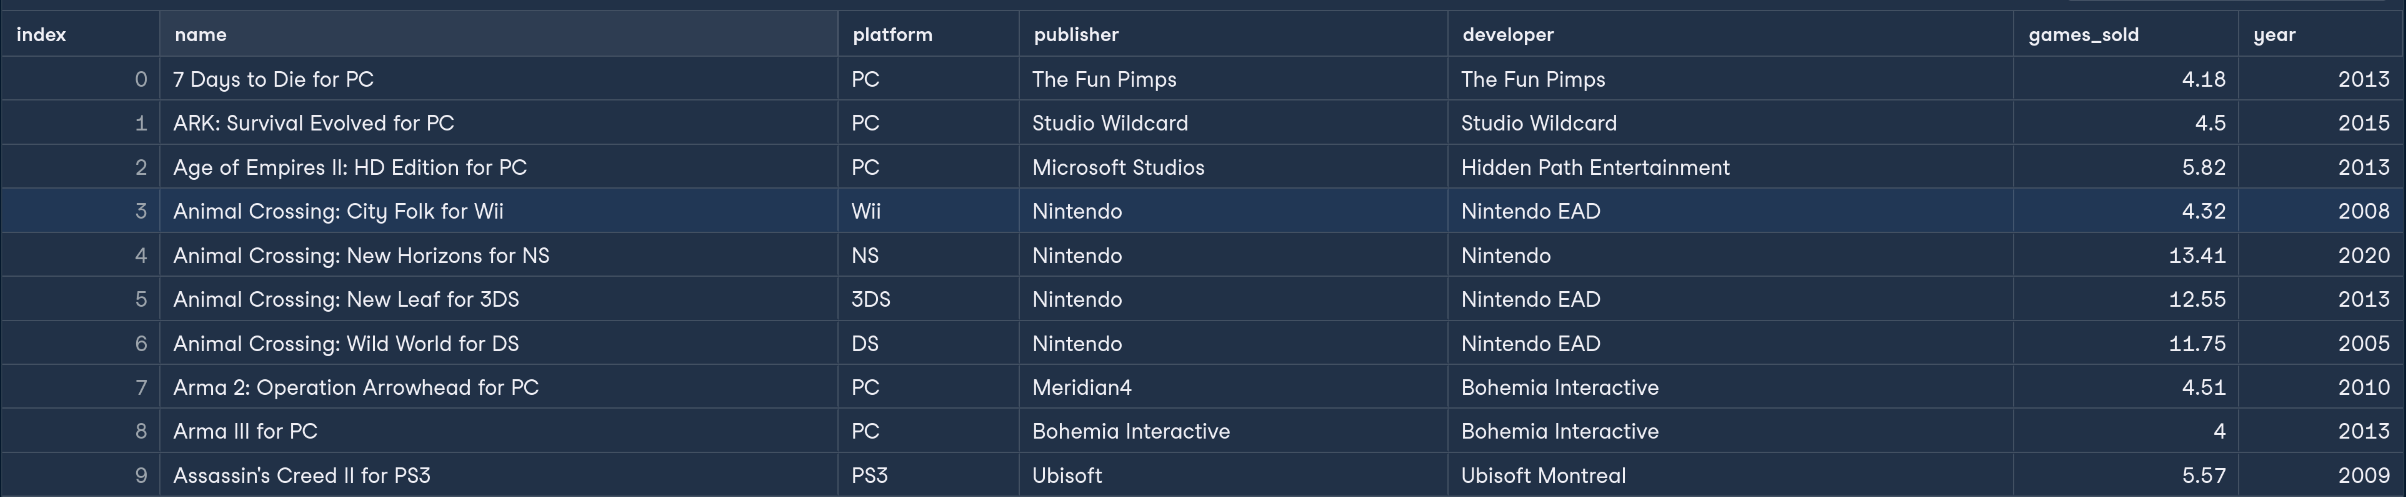

![game_reviews table.png](<attachment:game_reviews table.png>)
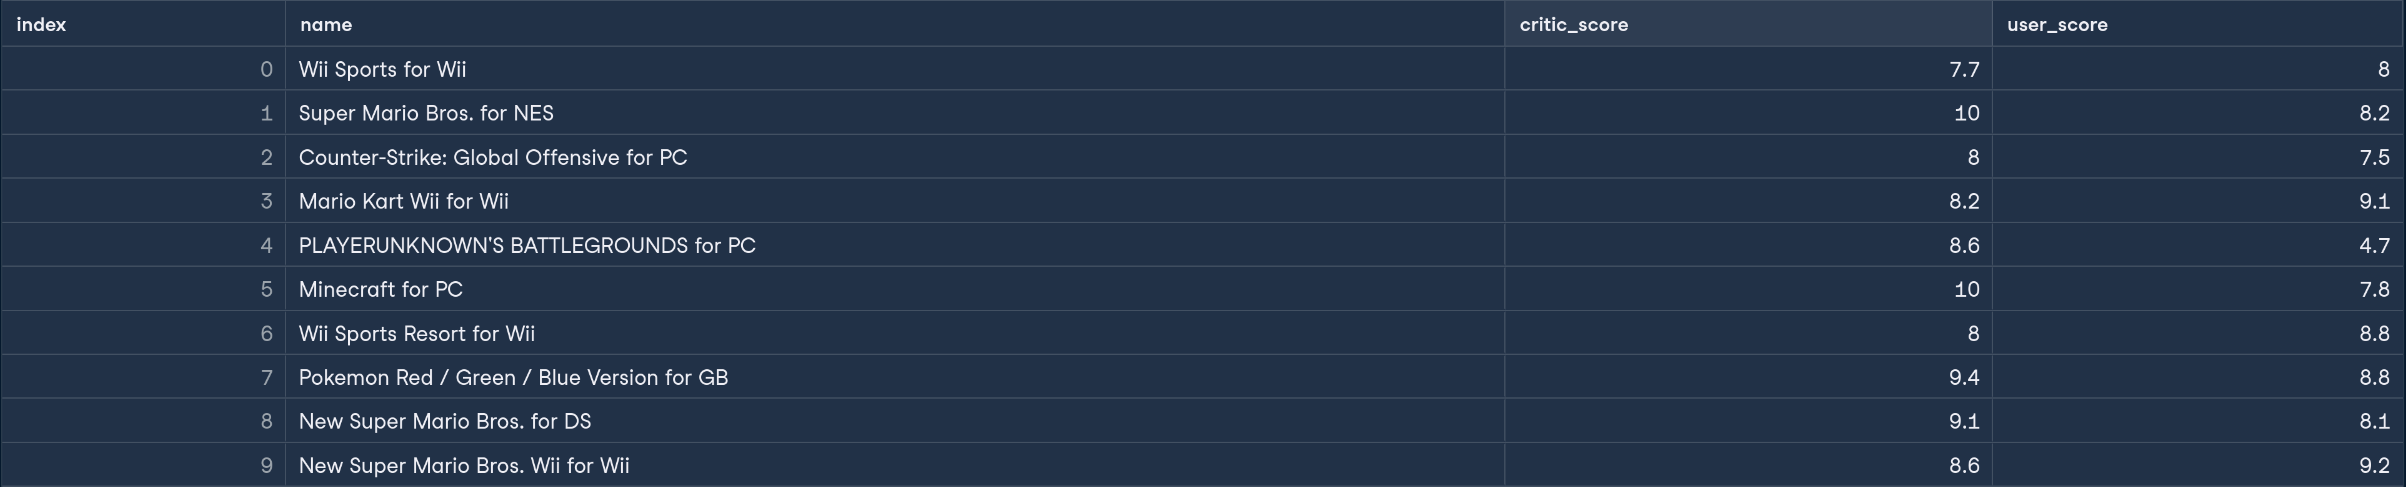

The code used for the analysis is presented below and is followed by the results it produces. Note that a filter was applied to include only years in which at least four games were released, and the results were limited to the 10 years with the highest average critic score. I should also note that, to showcase SQL’s functionalities, I added a filter selecting only years from 2000 onward, which was not present in my original code.

In [ ]:
SELECT year, COUNT(name) AS num_games, ROUND(AVG(critic_score), 2) AS avg_critic_score
  FROM game_sales
	     INNER JOIN reviews
       USING(name)
 WHERE year >= 2000
 GROUP BY year
	     HAVING COUNT(name) >= 4
 ORDER BY avg_critic_score DESC
 LIMIT 10;

![best 10 games of the 2000's.png](<attachment:best 10 games of the 2000's.png>)
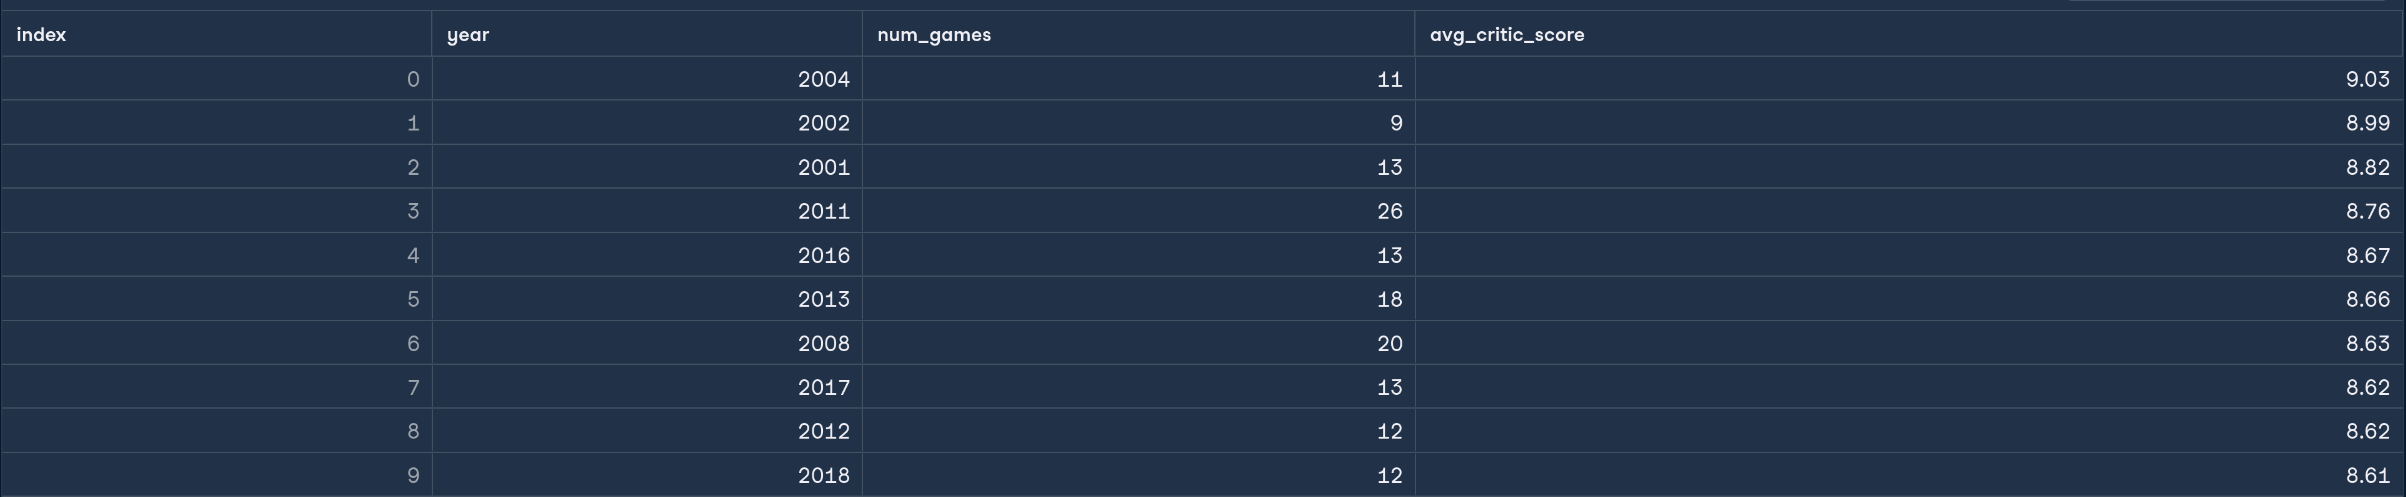

## Why is this Piece of Code Important?

Despite being fairly simple, the code above is important for highlighting a basic SQL principle that every data analyst should keep in mind when querying a database: **the order in which SQL code is executed differs from the order in which it is written**.

Even though the `SELECT` clause appears at the top of a query, the `FROM` clause is executed first and, along with any accompanying `JOIN` clauses, determines where the data will be extracted from. Next comes the `WHERE` clause, which filters the data to include only rows that meet specific conditions.

After selecting the relevant tables and filtering the rows, we can then `GROUP` the data `BY` distinct values present in one or more columns and apply aggregate functions such as `COUNT()` and `AVG()`, which are written in the `SELECT` clause. Before the `SELECT` clause is executed, though, we can further filter the grouped data using the `HAVING` clause. It is important to note here that, in contrast to `WHERE`, `HAVING` will filter the data based on aggregate values — as it is executed before `GROUP BY`, `WHERE` does not have any aggregate data to work with, which is why `HAVING` is required for such filters.

It is only after all of these clauses have been executed that `SELECT`, despite being the first clause in the written order, is actually run. Here, we can apply the aforementioned aggregate functions and alias the columns `AS` we want in order to avoid having to repeat the expressions that produce them. Note, however, that the aliases can only be used in clauses that come after their definition: because `HAVING` was executed before `SELECT`, I could not reference the alias "num_games" to filter the data, since it did not yet exist then — PostgreSQL actually allows such referencing, but this this is not SQL's standard behavior.

Finally, we can `ORDER` the results `BY` any column(s) we want in `ASC`ending or `DESC`ending order and also `LIMIT` the number of rows displayed.